# WTA Match Predictor — Modelo ML
Entrenamiento, evaluación y guardado del modelo. Requiere `historico_partidos.csv` y `wta_limpio.csv` generados por el notebook de EDA.

## 1. Imports

In [12]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier


## 2. Carga de datos

In [2]:
df = pd.read_csv('historico_partidos.csv', parse_dates=['date'])
print(f'Partidos cargados: {len(df)}')
print(df.info())

Partidos cargados: 42046
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42046 entries, 0 to 42045
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   match_id             42046 non-null  int64         
 1   date                 42046 non-null  datetime64[ns]
 2   odd_1                41958 non-null  float64       
 3   odd_2                41958 non-null  float64       
 4   surface              42046 non-null  object        
 5   round                42046 non-null  object        
 6   tournament_type      42046 non-null  object        
 7   rank_diff            42046 non-null  float64       
 8   wins2meses_p1        42046 non-null  float64       
 9   wins2meses_p2        42046 non-null  float64       
 10  ratio_superficie_p1  42046 non-null  float64       
 11  ratio_superficie_p2  42046 non-null  float64       
 12  h2h                  42046 non-null  float64       
 13  ratio_

## 3. Train / Test split

Split temporal — el test es siempre el período más reciente para simular condiciones reales de predicción.

In [3]:
corte = '2025-01-01'
df_train = df[df['date'] < corte].copy()
df_test  = df[df['date'] >= corte].copy()

print(f'Train: {len(df_train)} partidos ({df_train["date"].min().year}–{df_train["date"].max().year})')
print(f'Test:  {len(df_test)} partidos ({df_test["date"].min().year}–{df_test["date"].max().year})')
# Queda el test en el 8% (ampliar? cómo afecta esto)

Train: 38749 partidos (2008–2024)
Test:  3297 partidos (2025–2026)


In [4]:
df_test.columns

Index(['match_id', 'date', 'odd_1', 'odd_2', 'surface', 'round',
       'tournament_type', 'rank_diff', 'wins2meses_p1', 'wins2meses_p2',
       'ratio_superficie_p1', 'ratio_superficie_p2', 'h2h', 'ratio_ronda_p1',
       'ratio_ronda_p2', 'experiencia_p1', 'experiencia_p2', 'target',
       'is_new_p1', 'is_new_p2', 'elo_p1', 'elo_p2', 'elo_diff',
       'elo_global_p1', 'elo_global_p2', 'elo_global_diff'],
      dtype='object')

## 4. Tratamiento de outliers

Capeamos `rank_diff` usando los percentiles del train — nunca del test para evitar data leakage.

In [5]:
limite_superior = df_train['rank_diff'].quantile(0.90)
limite_inferior  = df_train['rank_diff'].quantile(0.10)
print (limite_inferior, limite_superior)
df_train['rank_diff'] = df_train['rank_diff'].clip(lower=limite_inferior, upper=limite_superior)
df_test['rank_diff']  = df_test['rank_diff'].clip(lower=limite_inferior, upper=limite_superior)

print(f'Límite inferior (p10%):  {limite_inferior}')
print(f'Límite superior (p90%): {limite_superior}')

-90.0 93.0
Límite inferior (p10%):  -90.0
Límite superior (p90%): 93.0


In [7]:
df_train.columns

Index(['match_id', 'date', 'odd_1', 'odd_2', 'surface', 'round',
       'tournament_type', 'rank_diff', 'wins2meses_p1', 'wins2meses_p2',
       'ratio_superficie_p1', 'ratio_superficie_p2', 'h2h', 'ratio_ronda_p1',
       'ratio_ronda_p2', 'experiencia_p1', 'experiencia_p2', 'target',
       'is_new_p1', 'is_new_p2', 'elo_p1', 'elo_p2', 'elo_diff',
       'elo_global_p1', 'elo_global_p2', 'elo_global_diff'],
      dtype='object')

## 5. Preparar X e y

In [8]:
# Columnas que no entran al modelo. 
cols_excluir = ['match_id', 'date', 'target', 'odd_1', 'odd_2']

X_train = df_train.drop(columns=cols_excluir)
X_test  = df_test.drop(columns=cols_excluir)
y_train = (df_train['target'] == 1).astype(int)
y_test  = (df_test['target'] == 1).astype(int)

print(f'Features: {X_train.columns.tolist()}')
print(f'Shape train: {X_train.shape} | test: {X_test.shape}')

Features: ['surface', 'round', 'tournament_type', 'rank_diff', 'wins2meses_p1', 'wins2meses_p2', 'ratio_superficie_p1', 'ratio_superficie_p2', 'h2h', 'ratio_ronda_p1', 'ratio_ronda_p2', 'experiencia_p1', 'experiencia_p2', 'is_new_p1', 'is_new_p2', 'elo_p1', 'elo_p2', 'elo_diff', 'elo_global_p1', 'elo_global_p2', 'elo_global_diff']
Shape train: (38749, 21) | test: (3297, 21)


In [48]:
# Verificar tipos y nulos
print(X_train.dtypes)
print('\nNulos:')
print(X_train.isnull().sum())

surface                 object
round                   object
tournament_type         object
rank_diff              float64
wins2meses_p1          float64
wins2meses_p2          float64
ratio_superficie_p1    float64
ratio_superficie_p2    float64
h2h                    float64
ratio_ronda_p1         float64
ratio_ronda_p2         float64
experiencia_p1           int64
experiencia_p2           int64
is_new_p1                int64
is_new_p2                int64
elo_p1                 float64
elo_p2                 float64
elo_diff               float64
elo_global_p1          float64
elo_global_p2          float64
elo_global_diff        float64
dtype: object

Nulos:
surface                0
round                  0
tournament_type        0
rank_diff              0
wins2meses_p1          0
wins2meses_p2          0
ratio_superficie_p1    0
ratio_superficie_p2    0
h2h                    0
ratio_ronda_p1         0
ratio_ronda_p2         0
experiencia_p1         0
experiencia_p2         0
is

In [9]:
# Guardar a archivo para subir a Github
X_train.to_csv ('X_train_v3.csv')
X_test.to_csv ('X_test_v3.csv')
y_train.to_csv ('y_train_v3.csv')
y_test.to_csv ('y_test_v3.csv')

## 6. Pipeline y preprocesador

In [10]:
cat_cols = ['surface', 'round','tournament_type']
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## 7. Modelos

In [32]:
# ── Random Forest ─────────────────────────────────────────────────────────────
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_params = {
    'classifier__max_depth': [2, 3, 5],
    'classifier__max_features': ['sqrt', 'log2', 0.3, 0.5], #al quitar una daba mejor. por probar
    'classifier__n_estimators': [100, 200]
}

random_best = GridSearchCV(estimator=pipe_rf, param_grid=rf_params, cv=5, n_jobs=-1)
random_best.fit(X_train, y_train)

print(f'Mejor score RF (CV): {random_best.best_score_:.2%}')
print(f'Mejores parámetros:  {random_best.best_params_}')

Mejor score RF (CV): 66.47%
Mejores parámetros:  {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}


In [33]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

xgb_params = {
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

xgb_best = GridSearchCV(estimator=pipe_xgb, param_grid=xgb_params, cv=5, n_jobs=-1)
xgb_best.fit(X_train, y_train)

print(f'Mejor score XGB (CV): {xgb_best.best_score_:.2%}')
print(f'Mejores parámetros:   {xgb_best.best_params_}')

Mejor score XGB (CV): 66.61%
Mejores parámetros:   {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}


In [ ]:
# mismo modelo quitando tournament_type da mejor

In [50]:
import pickle
from sklearn.ensemble import VotingClassifier

xgb_modelo = pickle.load(open('gbx_v3.model', 'rb'))
rf_modelo = pickle.load(open('random_v3.model', 'rb'))

voting = VotingClassifier(
    estimators=[
        ('xgb', xgb_modelo),
        ('rf', rf_modelo)
    ],
    voting='soft'
)

voting.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('xgb', ...), ('rf', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``s

## 8. Evaluación y comparativa

In [61]:
# Función de evaluación reutilizable
resultados = pd.DataFrame({
    'modelo':            pd.Series(dtype='str'),
    'parametros':        pd.Series(dtype='str'),
    'accuracy_modelo':   pd.Series(dtype='float'),
    'accuracy_casas':    pd.Series(dtype='float'),
    'accuracy_ranking':  pd.Series(dtype='float'),
    'correlacion_casas': pd.Series(dtype='float')
})


In [35]:

def evaluar_modelo(nombre, modelo_fit, X_test, y_test, df_test, df):
    y_pred  = modelo_fit.predict(X_test)
    y_proba = modelo_fit.predict_proba(X_test)[:, 1]

    acc_modelo = accuracy_score(y_test, y_pred)

    # Unir df_test con df para obtener las odds
    df_test_con_odds = df_test[['match_id']].copy()
    df_test_con_odds = df_test_con_odds.merge(df[['match_id', 'odd_1', 'odd_2']], 
                                               on='match_id', how='left')
    
    # Accuracy casas
    prob_1 = df_test_con_odds['odd_1'].values
    prob_2 = df_test_con_odds ['odd_2'].values
    mask   = ~np.isnan(prob_1) & ~np.isnan(prob_2)
    pred_casas = (prob_1[mask] > prob_2[mask]).astype(int)
    acc_casas  = accuracy_score(y_test[mask], pred_casas)

    # Accuracy baseline ranking
    pred_ranking = (df_test['rank_diff'] < 0).astype(int)
    acc_ranking  = accuracy_score(y_test, pred_ranking)

    # AUC modelo
    auc_modelo = roc_auc_score(y_test, y_proba)

    # AUC casas — usas sus probabilidades directamente
    prob_casas = df_test_con_odds['odd_1'].values
    mask = ~np.isnan(prob_casas)
    auc_casas = roc_auc_score(y_test[mask], prob_casas[mask])

    print(f'AUC modelo: {auc_modelo:.4f}')
    print(f'AUC casas:  {auc_casas:.4f}')
    print(f'Acc baseline:  {auc_casas:.4f}') 

    try:
        params = modelo_fit.best_params_
    except:
        params = {}

    nueva_fila = {
        'modelo':            nombre,
        'parametros':        str(params),
        'accuracy_modelo':   round(acc_modelo, 4),
        'accuracy_casas':    round(acc_casas, 4),
        'accuracy_ranking':  round(acc_ranking, 4),
        'AUC_modelo': round(auc_modelo, 4),
        'AUC casas':  round(auc_casas, 4)
    }
    return pd.concat([resultados, pd.DataFrame([nueva_fila])], ignore_index=True)

In [62]:
resultados = evaluar_modelo('Voting', voting, X_test, y_test, df_test, df)

AUC modelo: 0.7229
AUC casas:  0.7570
Acc baseline:  0.7570


In [63]:
resultados

,modelo,parametros,accuracy_modelo,accuracy_casas,accuracy_ranking,correlacion_casas,AUC_modelo,AUC casas
0,Voting,{},0.663,0.685,0.6272,NaN,0.7229,0.757


In [37]:
resultados = evaluar_modelo('Random Forest', random_best, X_test, y_test, df_test, df)
resultados = evaluar_modelo('XGBoost2', xgb_best, X_test, y_test, df_test, df)
resultados

AUC modelo: 0.7190
AUC casas:  0.7570
Acc baseline:  0.7570
AUC modelo: 0.7230
AUC casas:  0.7570
Acc baseline:  0.7570


,modelo,parametros,accuracy_modelo,accuracy_casas,accuracy_ranking,correlacion_casas,AUC_modelo,AUC casas
0,Random Forest,"{'classifier__max_depth': 5, 'classifier__max_...",0.6524,0.685,0.6272,NaN,0.719,0.757
1,XGBoost2,"{'classifier__colsample_bytree': 1.0, 'classif...",0.6573,0.685,0.6272,NaN,0.723,0.757
2,Random Forest,"{'classifier__max_depth': 5, 'classifier__max_...",0.6524,0.685,0.6272,NaN,0.719,0.757
3,XGBoost2,"{'classifier__colsample_bytree': 1.0, 'classif...",0.6573,0.685,0.6272,NaN,0.723,0.757


# Guardar resultados para trazabilidad

In [64]:
# Primeras features. Incluyendo todas
#resultados.to_csv ('resultados_features_v1.csv', index=False)

# QUitando tournament_type Y añadiendo en random forest classifier__max_features': 'sqrt'
#resultados.to_csv ('resultados_features_v2.csv', index=False) # --> el mejor está aquí xgboost

#Con ELO (sin inactividad)* listado abajo
#resultados.to_csv ('resultados_features_v3.csv', index=False)

# He probado quitando elos redundantes y dejando diferencias. No mejoraba. Se me ha olvidado guardar resultados
# Los dos mejores v3 en voting
resultados.to_csv ('resultados_features_v4.csv', index=False)

In [65]:
resultados1=pd.read_csv('resultados_features_v1.csv')
resultados2=pd.read_csv('resultados_features_v2.csv')
resultados3=pd.read_csv('resultados_features_v3.csv')
resultados4=pd.read_csv('resultados_features_v4.csv')

In [66]:
todos = pd.concat([resultados1,resultados2,resultados3, resultados4])

In [67]:
todos

,modelo,parametros,accuracy_modelo,accuracy_casas,accuracy_ranking,correlacion_casas,AUC_modelo,AUC casas
0,Random Forest,"{'classifier': RandomForestClassifier(), 'clas...",0.6351,0.685,0.6272,NaN,0.7043,0.757
1,XGBoost2,"{'classifier__colsample_bytree': 0.8, 'classif...",0.6482,0.685,0.6272,NaN,0.7102,0.757
0,Random Forest,"{'classifier__max_depth': 5, 'classifier__max_...",0.6400,0.685,0.6272,NaN,0.7041,0.757
1,XGBoost2,"{'classifier__colsample_bytree': 0.8, 'classif...",0.6494,0.685,0.6272,NaN,0.7108,0.757
0,Random Forest,"{'classifier__max_depth': 5, 'classifier__max_...",0.6624,0.685,0.6272,NaN,0.7227,0.757
1,XGBoost2,"{'classifier__colsample_bytree': 1.0, 'classif...",0.6621,0.685,0.6272,NaN,0.7242,0.757
0,Voting,{},0.6630,0.685,0.6272,NaN,0.7229,0.757


In [69]:
todos['parametros'].values

array(["{'classifier': RandomForestClassifier(), 'classifier__max_depth': 5, 'classifier__n_estimators': 200}",
       "{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}",
       "{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}",
       "{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}",
       "{'classifier__max_depth': 5, 'classifier__max_features': 0.5, 'classifier__n_estimators': 100}",
       "{'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}",
       '{}'], dtype=object)

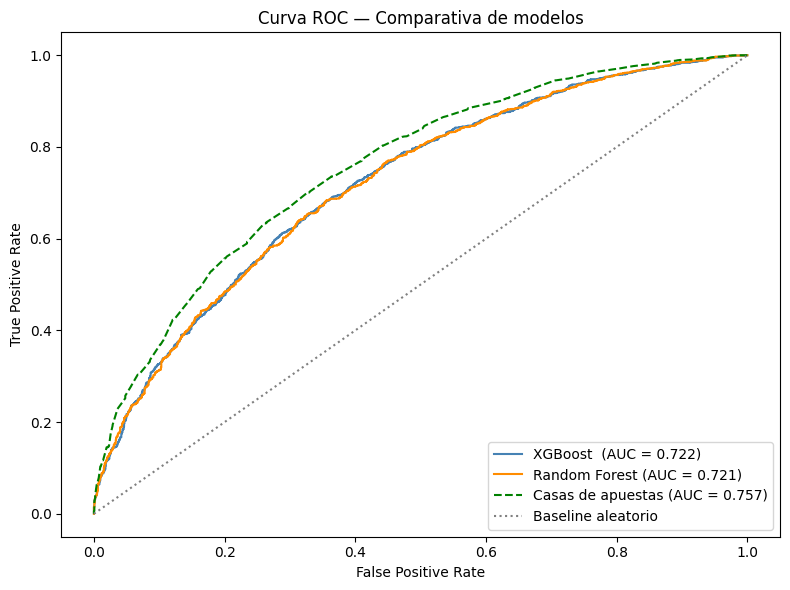

In [15]:
# ROC-AUC como métrica comparativa en gráfico

xgb_v3= pickle.load(open('gbx_v3.model', 'rb'))
random_v3 = pickle.load(open('random_v3.model', 'rb'))

# --- Probabilidades de cada modelo sobre el test ---
y_proba_xgb    = xgb_v3.predict_proba(X_test)[:, 1]
y_proba_rf     = random_v3.predict_proba(X_test)[:, 1]

# --- Probabilidades de las casas (prob_1 ya normalizada) ---
# Alineadas con Y_test
df_test_con_odds = df_test[['match_id']].merge(
    df[['match_id', 'odd_1']], on='match_id', how='left'
)
mask_casas     = df_test_con_odds['odd_1'].notna()
y_proba_casas  = df_test_con_odds.loc[mask_casas, 'odd_1'].values
y_test_casas   = y_test[mask_casas.values]

# --- Curvas ROC ---
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)
fpr_cas, tpr_cas, _ = roc_curve(y_test_casas, y_proba_casas)

auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_rf  = auc(fpr_rf,  tpr_rf)
auc_cas = auc(fpr_cas, tpr_cas)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost  (AUC = {auc_xgb:.3f})', color='steelblue')
ax.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC = {auc_rf:.3f})',  color='darkorange')
ax.plot(fpr_cas, tpr_cas, label=f'Casas de apuestas (AUC = {auc_cas:.3f})', color='green', linestyle='--')
ax.plot([0, 1], [0, 1],  label='Baseline aleatorio', color='grey', linestyle=':')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC — Comparativa de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_comparativa.png', dpi=150)
plt.show()

## 9. Feature importance

In [6]:
with open ('gbx_v3.model', 'rb') as archivo_entrada:
    modeloML = pickle.load(archivo_entrada)
print(modeloML)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['rank_diff', 'wins2meses_p1',
                                                   'wins2meses_p2',
                                                   'ratio_superficie_p1',
                                                   'ratio_superficie_p2', 'h2h',
                                                   'ratio_ronda_p1',
                                                   'ratio_ronda_p2',
                                                   'experiencia_p1',
                                                   'experiencia_p2',
                                                   'is_new_p1', 'is_new_p2',
                                                   'elo_p1', 'elo_p2',
                                                   'elo_diff', 'elo_global_p1',
                                                   'elo_global_p2',
                

In [8]:
with open ('random_v3.model', 'rb') as archivo_entrada:
    modeloML_random = pickle.load(archivo_entrada)

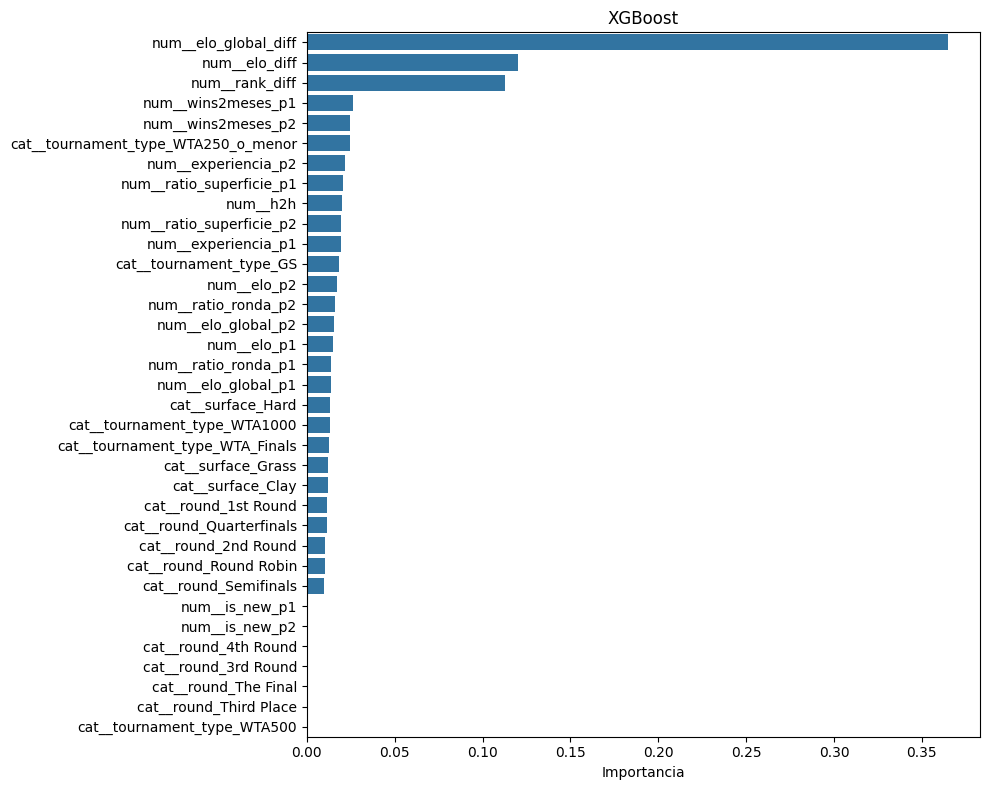

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))

classes      = modeloML.named_steps['preprocessor'].get_feature_names_out()
importancias = modeloML.named_steps['classifier'].feature_importances_

df_imp = pd.DataFrame({'feature': classes, 'importancia': importancias})
df_imp = df_imp.sort_values('importancia', ascending=False)

sns.barplot(data=df_imp, x='importancia', y='feature', ax=ax)
ax.set_title('XGBoost')
ax.set_xlabel('Importancia')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

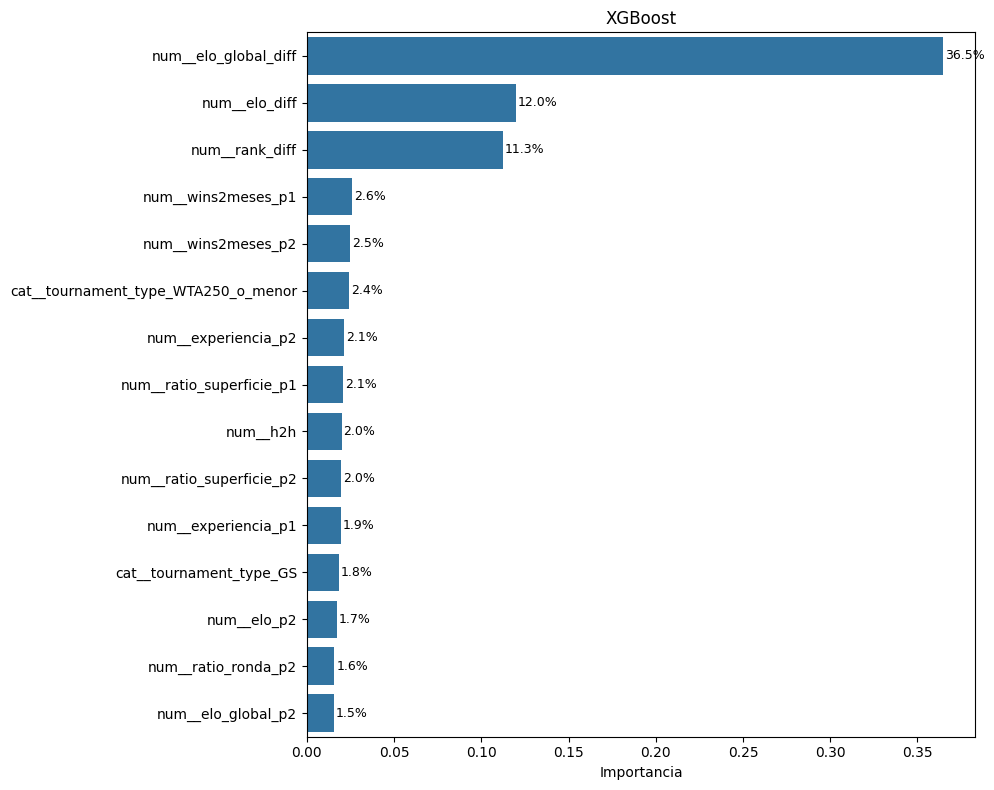

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

classes      = xgb_v3.named_steps['preprocessor'].get_feature_names_out()
importancias = xgb_v3.named_steps['classifier'].feature_importances_

df_imp_xbg = pd.DataFrame({'feature': classes, 'importancia': importancias})
df_imp_xbg = df_imp_xbg.sort_values('importancia', ascending=False).head(15)

sns.barplot(data=df_imp_xbg, x='importancia', y='feature', ax=ax)

for bar, valor in zip(ax.patches, df_imp_xbg['importancia']):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{valor:.1%}',
        va='center', ha='left', fontsize=9
    )

ax.set_title('XGBoost')
ax.set_xlabel('Importancia')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [13]:
print(df_imp)

                                feature  importancia
17                 num__elo_global_diff     0.364866
14                        num__elo_diff     0.120124
0                        num__rank_diff     0.112655
1                    num__wins2meses_p1     0.026069
2                    num__wins2meses_p2     0.024816
32  cat__tournament_type_WTA250_o_menor     0.024361
9                   num__experiencia_p2     0.021489
3              num__ratio_superficie_p1     0.020851
5                              num__h2h     0.019937
4              num__ratio_superficie_p2     0.019563
8                   num__experiencia_p1     0.019488
30              cat__tournament_type_GS     0.018445
13                          num__elo_p2     0.017169
7                   num__ratio_ronda_p2     0.015841
16                   num__elo_global_p2     0.015298
12                          num__elo_p1     0.014796
6                   num__ratio_ronda_p1     0.013893
15                   num__elo_global_p1     0.

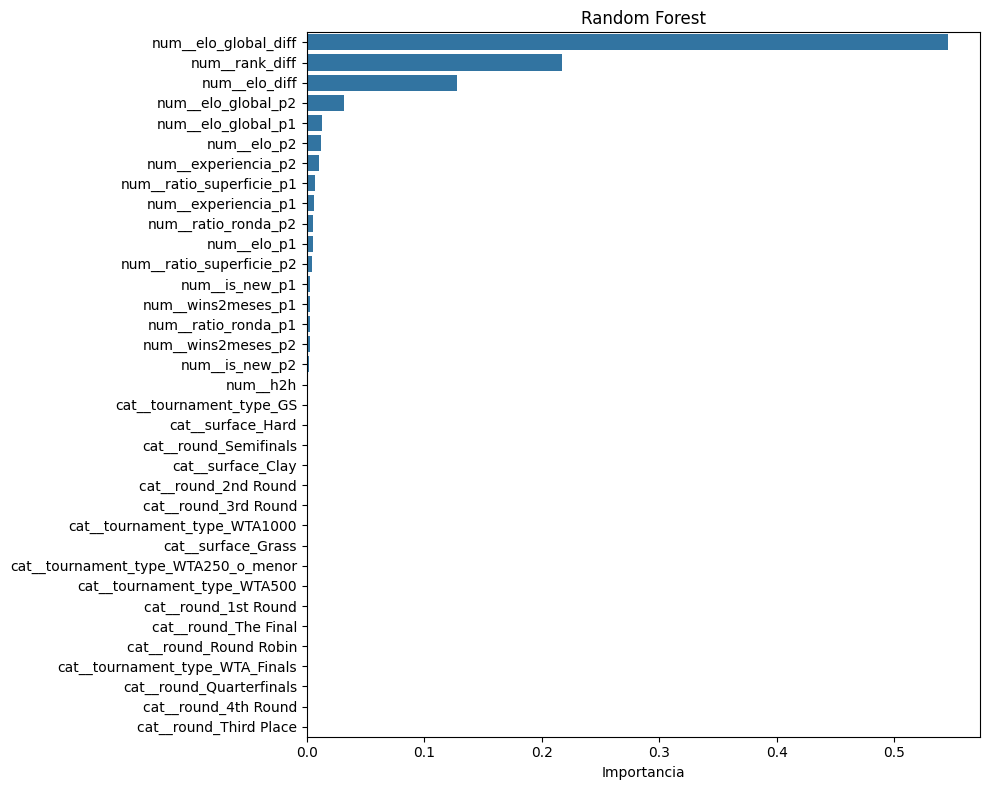

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

classes      = modeloML_random.named_steps['preprocessor'].get_feature_names_out()
importancias = modeloML_random.named_steps['classifier'].feature_importances_

df_imp_ran = pd.DataFrame({'feature': classes, 'importancia': importancias})
df_imp_ran = df_imp_ran.sort_values('importancia', ascending=False)

sns.barplot(data=df_imp_ran, x='importancia', y='feature', ax=ax)
ax.set_title('Random Forest')
ax.set_xlabel('Importancia')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [15]:
print(df_imp_ran)

                                feature  importancia
17                 num__elo_global_diff     0.545755
0                        num__rank_diff     0.217032
14                        num__elo_diff     0.127921
16                   num__elo_global_p2     0.031836
15                   num__elo_global_p1     0.012871
13                          num__elo_p2     0.012106
9                   num__experiencia_p2     0.010618
3              num__ratio_superficie_p1     0.006878
8                   num__experiencia_p1     0.006481
7                   num__ratio_ronda_p2     0.005404
12                          num__elo_p1     0.004914
4              num__ratio_superficie_p2     0.004279
10                       num__is_new_p1     0.002785
1                    num__wins2meses_p1     0.002713
6                   num__ratio_ronda_p1     0.002421
2                    num__wins2meses_p2     0.002401
11                       num__is_new_p2     0.002065
5                              num__h2h     0.

## 10. Guardar el modelo

In [66]:
# Guardar el mejor modelo (XGBoost) para usar en la app de Streamlit
with open('random_v3.model', 'wb') as f:
    pickle.dump(random_best.best_estimator_, f)

print('Modelo guardado en gbx_red.model')

Modelo guardado en gbx_red.model


In [ ]:
# 0   match_id             42046 non-null  int64         
#  1   date                 42046 non-null  datetime64[ns]
#  2   odd_1                41958 non-null  float64       
#  3   odd_2                41958 non-null  float64       
#  4   surface              42046 non-null  object        
#  5   round                42046 non-null  object        
#  6   tournament_type      42046 non-null  object        
#  7   rank_diff            42046 non-null  float64       
#  8   wins2meses_p1        42046 non-null  float64       
#  9   wins2meses_p2        42046 non-null  float64       
#  10  ratio_superficie_p1  42046 non-null  float64       
#  11  ratio_superficie_p2  42046 non-null  float64       
#  12  h2h                  42046 non-null  float64       
#  13  ratio_ronda_p1       42046 non-null  float64       
#  14  ratio_ronda_p2       42046 non-null  float64       
#  15  experiencia_p1       42046 non-null  int64         
#  16  experiencia_p2       42046 non-null  int64         
#  17  target               42046 non-null  int64         
#  18  is_new_p1            42046 non-null  int64         
#  19  is_new_p2            42046 non-null  int64         
#  20  elo_p1               42046 non-null  float64       
#  21  elo_p2               42046 non-null  float64       
#  22  elo_diff             42046 non-null  float64       
#  23  elo_global_p1        42046 non-null  float64       
#  24  elo_global_p2        42046 non-null  float64       
#  25  elo_global_diff      42046 non-null  float64       